# Baseline Model Tests
Here we run the following models

* Decision Tree Classifier (scikit-learn)
* Random Forest Classifier (scikit-learn)
* XGboost Classifier

and get a baseline understanding on how well the meteorological, temporal, and geo-spatial data we have at our disposal captures the probability that a tornado occurs near/around stations in Oklahoma City. 

The **Decision Tree Classifier** is our basic model, the **Random Forest Classifier** is our mid-level model, and the **XGboost Classifier** is our more advanced model. As our label is highly unbalanced (tornadoes are rare events), we measure performance with:

* Recall with scikit-learn's `recall_score`
    * Given by $$R=\frac{T_p}{T_p+F_n},$$ where $T_p$ is the number of true positives and $F_n$ is the number of false negatives.
    * Helps with detect False Negatives (especially important for tornadoes). A Recall score of 1 is ideal; 0 is the worst.
* Precision with scikit-learn's `precision_score`
    * Given by $$P=\frac{T_p}{T_p+F_p},$$ where $T_p$ is the number of true positives and $F_p$ is the number of false positives.
    * Helps with detect False Positives. A Precision score of 1 is ideal; 0 is the worst. 
    * While false positives are less than ideal, we will put more weight on false negatives (recall score) since this our goal is predicting tornado occurrence.
* F2-score with scikit-learn's `fbeta_score`.
    *$$F2 =\frac{(1+2^2)(\mathrm{precision}\cdot \mathrm{recall})}{(2^2\mathrm{precision})+\mathrm{recall}}$$
    * Provides a single measure  both false positives and false negatives.
    * Useful for overall summary of detection performance.
* Average Precision with scikit-learn's `average_precision_score`
    * Area under the Precision-Recall curve (PR-AUC) given by plotting precision versus recall at various thresholds.
    * A weighted mean of the precision across with weights being differences in recall values across successive threshold values.
    * Informative metric for unbalanced target columns such as ours.
* ROC-AUC with scikit-learn's `roc_auc_score`
    * Area under the Receiver Operating Characteristic curve (ROC-AUC)given by plotting true positive rates over false positive rates at various thresholds.
    * Gives a sense on if the model is learning how to differentiate between conditions leading to tornadic and non-tornadic events even if the `Average Precision` (see below) score is low. 
    * Threshold independent.
    * Can appear overly optimistic in cases of severe class imbalance (like ours). Hence, we treat it as a secondary indicator of whether the model is learning to rank conditions leading to tornadic events versus non-tornadic events.

In order of importance our key metrics are:
1. Recall
2. Average Precision (PR-AUC)
3. Precision
4. F2-Score
5. ROC-AUC

## 1. Our Target - A Brief Summary

After running

```python
data = create_tornado_indicator(time_window=1,val_radius=50)
```

each row in the dataset represents a **station-hour observation**  with:
- Meteorological readings from a weather `val_radius` kilometers away (there may be more than one station).
- Tornado occurrence metadata (begin/end latitudes, longitudes, time).
- Station information (id number, lat,lon coordinates, elevation,...)

Our prediction target is a Boolean variable:
> `TORNADO_OCCURRENCE ∈ {0, 1}` — whether a tornado was active near the station within the prior `time_window` hours.


## 2. Getting the Data

### 2.1 Imports

In [1]:
## Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import notebook_file_utilities.auto_add_project_root as proroot
import pathlib

# For reading in modules from src and reading/saving files
project_root = proroot.auto_add_project_root()

# Pipeline
from src.pipeline.preprocessing import preprocessing
from src.pipeline.feature_engineering import pre_train_test_split_FE
from src.pipeline.drop_cols import (
    pre_split_drop,
    post_split_drop
)
# Read in Data
from src.cleaning.merged_tornado_indicator import create_tornado_indicator



### 2.2 Read in Data

In [2]:
# Read in data
data = create_tornado_indicator(time_window=1,val_radius=50)

/Users/taylormurray/Documents/GitHub/fall-2025-predicting-tornadoes/src/cleaning/clean_stations.py:93: DtypeWarning: Columns (7,14,15,16,17,19,20,21,22,23,24,25,26,27,28,29,30,32,33,34,40,41,42,43,44,45,46,47,50,51,52,56,57,58,59,60,65,68,69,70,71,76,79,80,81,82,83,90,91,92,93,94,95,96,97,98,99,102,104,105,106,110,111,113,120,121,122,125) have mixed types. Specify dtype option on import or set low_memory=False.
  station_dfs=[pd.read_csv(os.path.join(station_dir,file)).copy() for file in station_csv_files]
/Users/taylormurray/Documents/GitHub/fall-2025-predicting-tornadoes/src/cleaning/clean_stations.py:93: DtypeWarning: Columns (39,40,41,42,43,47,48,52,53,54,55,57,58,59,60,61,65,70,71,76,77,88,89,106,108,109,110) have mixed types. Specify dtype option on import or set low_memory=False.
  station_dfs=[pd.read_csv(os.path.join(station_dir,file)).copy() for file in station_csv_files]
/Users/taylormurray/Documents/GitHub/fall-2025-predicting-tornadoes/src/cleaning/clean_stations.py:93: Dt

## 3. Baseline Pipeline

The main baseline pipeline is split up into the following mini-pipelines

* The pipeline `preprocessing` from [src/pipeline/preprocessing.py](<../src/pipeline/preprocessing.py>).

* The function `pre_split_drop` from [src/pipeline/drop_cols.py](<../src/pipeline/drop_cols.py>) returns a pipeline that drops 
    * 'TORNADO_BEGIN_DATE_TIME',
    * 'TORNADO_END_DATE_TIME',
    * 'TORNADO_BEGIN_LAT',
    * 'TORNADO_BEGIN_LON',
    * 'TORNADO_END_LAT',
    * 'TORNADO_END_LON',
    * 'TORNADO_INITIAL_DISTANCE_FROM_STATION',
    * 'TORNADO_INITIAL_DISTANCE_FROM_STATION_WITHIN_50_km',

with a parameter `pre_cols_to_drop` to drop additional columns before we Test-Train split the data.

* The pipeline `Pre_Train_Test_Split_FE` from [src/pipeline/feature_engineering.py](<../src/pipeline/drop_cols.py>)

* Train-Test Split by putting setting aside data from the years 2000-2017 as training data and data from the years 2018-2021 as testing data. We do it this way since our goal is to predict tornadoes, and this is a very easy way to prevent temporal data leakage.

* The function `post_split_drop` from [src/pipeline/drop_cols.py](<../src/pipeline/drop_cols.py>) returns a pipeline that drops 
    * 'STATION',
    * 'WND- Wind Observation- Type Code',
    * 'STATION_DATE_TIME'

with a parameter `post_cols_to_drop` after we Test-Train split the data.

### 3.1 Preprocessing Pipeline

In [3]:
# Preprocess Pipeline
#data = preprocessing.fit_transform(data)
data = preprocessing.fit_transform(data)


### 3.2 Pre Split Drop 

In [4]:
# Pre Split Column Drop
data = pre_split_drop().fit_transform(data)


### 3.3 Pre Split Feature Engineering

In [5]:
# Pre Split Feature Engineering

data = pre_train_test_split_FE.fit_transform(data)

### 3.4 Split Data

To reiterate:  we set aside data from the years 2000-2017 as training data and data from the years 2018-2021 as testing data. We do it this way since our goal is to predict tornadoes, and this is a very easy way to prevent temporal data leakage.

In [6]:
# Split
# Hold data from years 2019-2021 aside for test data
# Years 2000-2018 for train

data_train = data[data['year']<=2017]
data_test = data[data['year']> 2017]


### 3.5 Set Aside Labels

In [7]:
X_train = data_train.drop(columns = 'TORNADO_OCCURRENCE')
y_train = data_train['TORNADO_OCCURRENCE']
X_test = data_test.drop(columns = 'TORNADO_OCCURRENCE')
y_test = data_test['TORNADO_OCCURRENCE']

### 3.6 Test/Training Stats

We check that the desired training years are in our test and training sets. We also check the label inbalance ratios in both the test set and training set. Lastly, we compute the Train-Test Ratios. The output is printed here for convenience

``` output
Train years: [np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]
Test years: [np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]
Train tornado ratio: 0.0081
Test tornado ratio: 0.0124
Train-Test Ratios: 0.7623997968732997 0.23760020312670027
```

In [8]:
print("Train years:", sorted(data_train['year'].unique()))
print("Test years:", sorted(data_test['year'].unique()))
print("Train tornado ratio:", y_train.mean().round(4))
print("Test tornado ratio:", y_test.mean().round(4))
print("Train-Test Ratios:", len(X_train)/len(data), len(X_test)/len(data) )

# tornado ratio is lower in train than test


Train years: [np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]
Test years: [np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]
Train tornado ratio: 0.0081
Test tornado ratio: 0.0124
Train-Test Ratios: 0.7623997968732997 0.23760020312670027


### 3.7 Post Split Column Drop

In [9]:
# Post Train-Test Split Column Drop

X_train = post_split_drop().fit_transform(X_train)
X_test = post_split_drop().fit_transform(X_test)


## 4. Baseline Models

### Modeling Imports

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.metrics import (classification_report, 
                            roc_auc_score,
                            confusion_matrix,
                            average_precision_score,
                            precision_recall_curve,
                            fbeta_score,
                            recall_score,
                            precision_score,
                            ConfusionMatrixDisplay)


#########################

# A helpful function for summary metrics
# Putting here for time being.

# For recording results
results_df = pd.DataFrame()

def summarize_metrics(model,
                    model_name,
                    X_test,
                    y_test,
                    threshold = None):
    if threshold is None:
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]
        threshold = 0.5
    else: 
        probs = model.predict_proba(X_test)[:,1]
        preds = (probs >= threshold).astype(int)
    
    params = model.get_params()
    metrics = {
        "Model": model_name,
        "Parameters" : params,
        "Threshold": threshold,
        "Recall": recall_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "F2": fbeta_score(y_test, preds, zero_division=0,beta=2),
        "roc_auc": roc_auc_score(y_test, probs),
        "avg_precision": average_precision_score(y_test, probs),
    }
    return metrics, preds, probs




##########################



### Decision Tree Classifier

In [11]:

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

metrics,preds_tree,probs_tree = summarize_metrics(tree, 
                                        "Unbalanced Decision Tree",
                                        X_test,
                                        y_test)

results_df = pd.concat([results_df,pd.DataFrame([metrics])],ignore_index=True)

print(f"Decision Tree Results:")
pd.DataFrame([metrics])







Decision Tree Results:


,Model,Parameters,Threshold,Recall,Precision,F2,roc_auc,avg_precision
0,Unbalanced Decision Tree,"{'ccp_alpha': 0.0, 'class_weight': None, 'crit...",0.5,0.004914,0.031008,0.005908,0.532712,0.016383


In [12]:
results_df

,Model,Parameters,Threshold,Recall,Precision,F2,roc_auc,avg_precision
0,Unbalanced Decision Tree,"{'ccp_alpha': 0.0, 'class_weight': None, 'crit...",0.5,0.004914,0.031008,0.005908,0.532712,0.016383


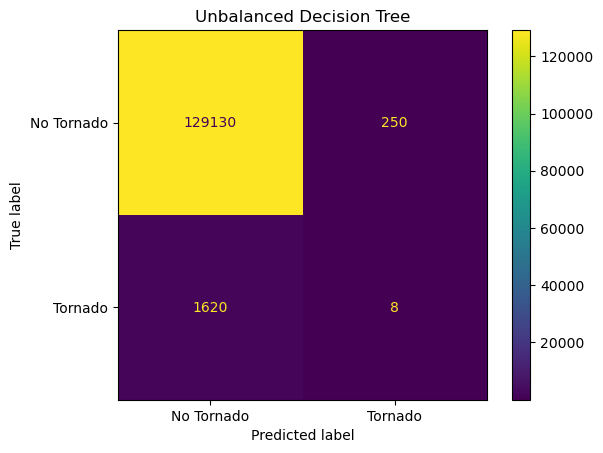

In [13]:

tree_cm=confusion_matrix(y_test, preds_tree,labels =[False, True])
tree_cmd = ConfusionMatrixDisplay(tree_cm,display_labels=['No Tornado', 'Tornado'])
tree_cmd.plot()
plt.title('Unbalanced Decision Tree')
path = pathlib.Path('results/baseline_model_figures/unbalanced_tree.png')
plt.savefig(project_root/path)
plt.show()



#### Unbalanced Decision Tree Evaluation
**Parameters:** Default settings with no class weighting.  

**Threshold:** 0.5  

**Performance:**  
- Recall: 0.0049  
- Precision: 0.0310  
- F₂-score: 0.0059  
- ROC-AUC: 0.533  
- PR-AUC: 0.016  

**Interpretation:**  
The unbalanced decision tree captures a very small fraction of tornado occurrences, identifying 8 true positives out of 1,628 events. Its ROC-AUC begin just slightly larger than 0.5 indicates minimal discriminatory ability. This model primarily predicts the majority class, showing the need for class rebalancing or threshold adjustment.

---

### Decision Tree Classifier (class_weight ='balanced')

In [14]:
tree_weighted = DecisionTreeClassifier(random_state=42, class_weight='balanced')
tree_weighted.fit(X_train, y_train)

metrics,preds_w,probs_w = summarize_metrics(tree_weighted, 
                                        "Balanced Decision Tree",
                                        X_test,
                                        y_test)
results_df = pd.concat([results_df,pd.DataFrame([metrics])],ignore_index=True)

pd.DataFrame([metrics])

,Model,Parameters,Threshold,Recall,Precision,F2,roc_auc,avg_precision
0,Balanced Decision Tree,"{'ccp_alpha': 0.0, 'class_weight': 'balanced',...",0.5,0.006143,0.055249,0.00747,0.502409,0.012725


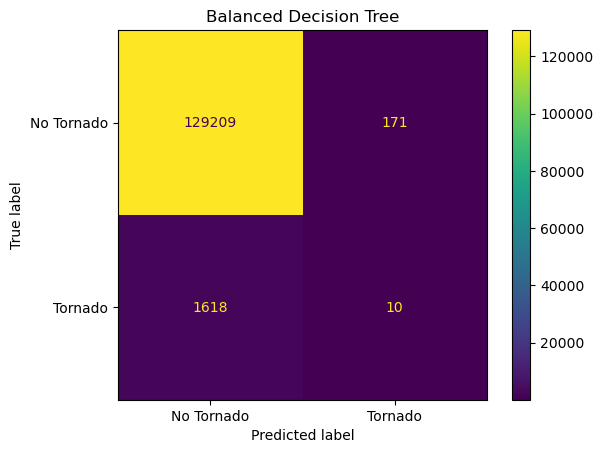

In [15]:
tree_weighted_cm=confusion_matrix(y_test, preds_w,labels =[False, True])
tree_weighted_cmd = ConfusionMatrixDisplay(tree_weighted_cm,display_labels=['No Tornado', 'Tornado'])
tree_weighted_cmd.plot()
plt.title('Balanced Decision Tree')
path = pathlib.Path('results/baseline_model_figures/balanced_tree.png')
plt.savefig(project_root/path)
plt.show()

#### Balanced Decision Tree Evaluation
**Parameters:** `class_weight='balanced'`  
**Threshold:** 0.5  
**Performance:**  
- Recall: 0.0061  
- Precision: 0.0552  
- F₂-score: 0.0075  
- ROC-AUC: 0.502  
- PR-AUC: 0.013  

**Interpretation:**  
Introducing class weighting slightly improves recall and precision but overall performance remains weak. The model captures around 10 tornado events but continues to predict nearly all samples as “No Tornado.” Furthermore, its ROC-AUC score indicates random ranking. This suggests that a single-tree model lacks capacity to model rare-event structure in this dataset. 

---

### Random Forest Classifier (RFC)

In [16]:
rfc= RandomForestClassifier(n_estimators=200,random_state=42)

rfc.fit(X_train,y_train)

metrics,preds_rfc,probs_rfc = summarize_metrics(rfc, 
                                        "Random Forest Classifier",
                                        X_test,
                                        y_test)
results_df = pd.concat([results_df,pd.DataFrame([metrics])],ignore_index=True)

pd.DataFrame([metrics])




,Model,Parameters,Threshold,Recall,Precision,F2,roc_auc,avg_precision
0,Random Forest Classifier,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",0.5,0.0,0.0,0.0,0.839385,0.067951


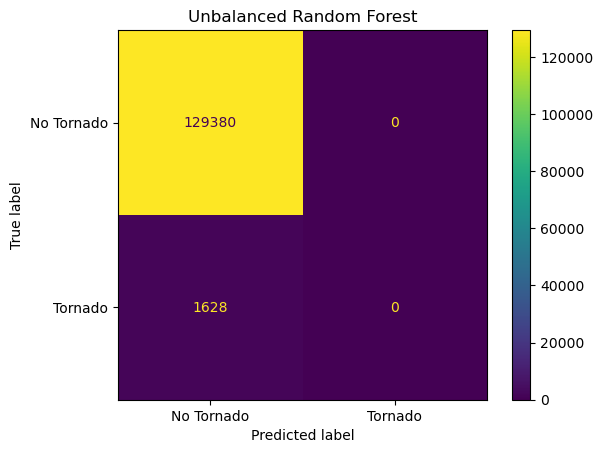

In [17]:
rfc_cm=confusion_matrix(y_test, preds_rfc,labels =[False, True])
rfc_cmd = ConfusionMatrixDisplay(rfc_cm,display_labels=['No Tornado', 'Tornado'])
rfc_cmd.plot()
plt.title('Unbalanced Random Forest')
path = pathlib.Path('results/baseline_model_figures/unbal_random_forest.png')
plt.savefig(project_root/path)
plt.show()

#### 3. Unbalanced Random Forest Evaluation
**Parameters:** 200 estimators, default class weights.  
**Threshold:** 0.5  
**Performance:**  
- Recall: 0.0000  
- Precision: 0.0000  
- F₂-score: 0.0000  
- ROC-AUC: 0.839  
- PR-AUC: 0.068  

**Interpretation:**  
While the model fails to predict any tornadoes (recall = 0), the ROC-AUC value of 0.84 shows that the model **learns a useful ranking** of tornado versus non-tornado conditions. Tornadoes are very rare events and the 0.5 threshold won't capture these. This points to the need for threshold tuning or probability calibration.

---

### RFC (class_weight = balanced_subsample)

In [18]:
rfc_w= RandomForestClassifier(n_estimators=200,random_state=42,class_weight='balanced_subsample')

rfc_w.fit(X_train,y_train)

metrics,preds_rfc_w,probs_rfc_w= summarize_metrics(rfc_w, 
                                        "Balanced Random Forest Classifier",
                                        X_test,
                                        y_test)
results_df = pd.concat([results_df,pd.DataFrame([metrics])],ignore_index=True)

pd.DataFrame([metrics])



,Model,Parameters,Threshold,Recall,Precision,F2,roc_auc,avg_precision
0,Balanced Random Forest Classifier,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",0.5,0.0,0.0,0.0,0.677136,0.031857


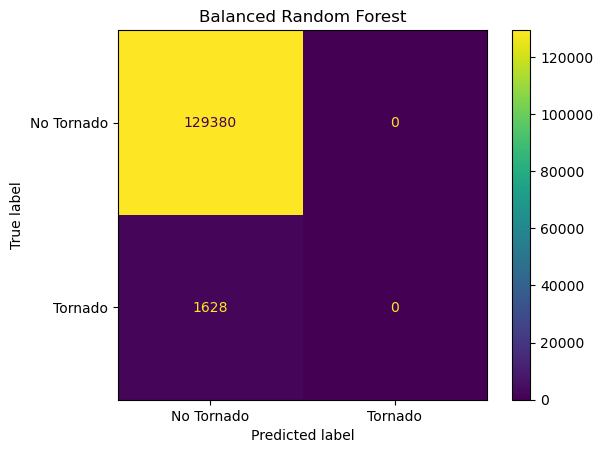

In [19]:
rfc_cm_w=confusion_matrix(y_test, preds_rfc_w,labels =[False, True])
rfc_cmd_w = ConfusionMatrixDisplay(rfc_cm_w,display_labels=['No Tornado', 'Tornado'])
rfc_cmd_w.plot()
plt.title('Balanced Random Forest')
path = pathlib.Path('results/baseline_model_figures/bal_random_forest.png')
plt.savefig(project_root/path)
plt.show()

#### Balanced Random Forest Evaluation
**Parameters:** `class_weight='balanced_subsample'`  
**Threshold:** 0.5  
**Performance:**  
- Recall: 0.0000  
- Precision: 0.0000  
- F₂-score: 0.0000  
- ROC-AUC: 0.677  
- PR-AUC: 0.032  

**Interpretation:**  
Applying balanced subsampling did not improve detection performance; the model still predicts all samples as “No Tornado.” The moderate ROC-AUC suggests that balancing reduced general discrimination power.

---


### XGBoost Classifier

In [22]:


xg = XGBClassifier(use_label_encoder=False, eval_metric='aucpr', random_state=42)

xg.fit(X_train, y_train)

metrics,preds_xg,probs_xg = summarize_metrics(xg, 
                                        "Unbalanced XGBoost",
                                        X_test,
                                        y_test)
results_df = pd.concat([results_df,pd.DataFrame([metrics])],ignore_index=True)

pd.DataFrame([metrics])


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [18:20:33] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1744329023465/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Model,Parameters,Threshold,Recall,Precision,F2,roc_auc,avg_precision
0,Unbalanced XGBoost,"{'objective': 'binary:logistic', 'base_score':...",0.5,0.0,0.0,0.0,0.865125,0.065498


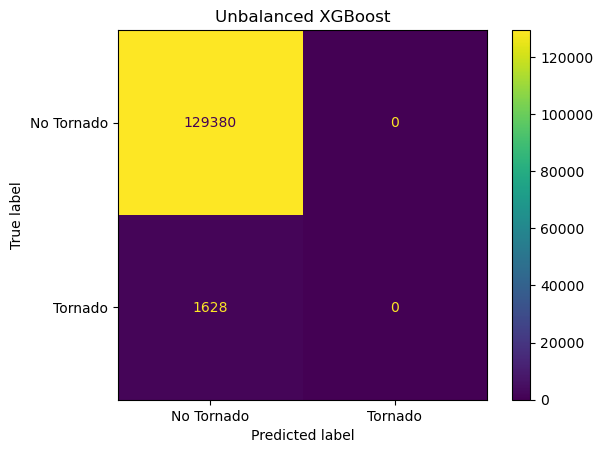

In [23]:

cm_xg=confusion_matrix(y_test, preds_xg,labels =[False, True])
cmd_xg = ConfusionMatrixDisplay(cm_xg,display_labels=['No Tornado', 'Tornado'])
cmd_xg.plot()
plt.title('Unbalanced XGBoost')
path = pathlib.Path('results/baseline_model_figures/bal_xgboost.png')
plt.savefig(project_root/path)
plt.show()

#### Unbalanced XGBoost Evaluation
**Parameters:** Default XGBoost configuration with `eval_metric='aucpr'`.  
**Threshold:** 0.5  
**Performance:**  
- Recall: 0.0000  
- Precision: 0.0000  
- F₂-score: 0.0000  
- ROC-AUC: 0.865  
- PR-AUC: 0.065  

**Interpretation:**  
This model achieves the **highest ROC-AUC (0.865)** of all baselines, suggesting strong ranking ability despite predicting no tornado events at the 0.5 threshold. The pattern mirrors Random Forest behavior: the model learns meaningful probability structure but is conservative in labeling positive events. Threshold adjustment should improve recall.

---

### Balanced XGBoost 

In [24]:

scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
bxg = XGBClassifier(
    use_label_encoder=False,
    eval_metric='aucpr',
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

bxg.fit(X_train, y_train)
metrics,preds_bxg,probs_bxg = summarize_metrics(bxg, 
                                        "Balanced XGBoost",
                                        X_test,
                                        y_test)
results_df = pd.concat([results_df,pd.DataFrame([metrics])],ignore_index=True)

pd.DataFrame([metrics])


/opt/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [18:20:34] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1744329023465/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Model,Parameters,Threshold,Recall,Precision,F2,roc_auc,avg_precision
0,Balanced XGBoost,"{'objective': 'binary:logistic', 'base_score':...",0.5,0.0,0.0,0.0,0.802131,0.045301


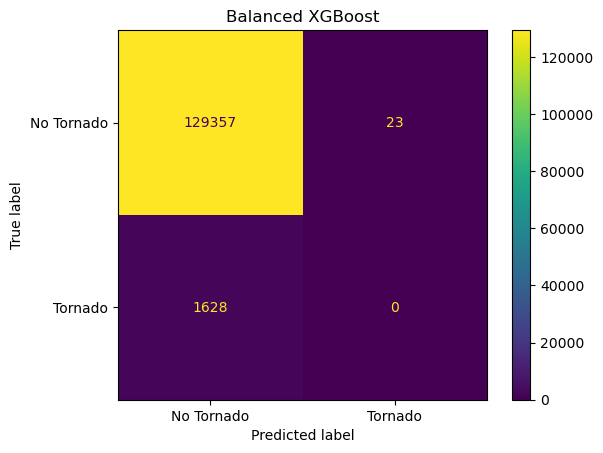

In [25]:
cm_bxg=confusion_matrix(y_test, preds_bxg,labels =[False, True])
cmd_bxg = ConfusionMatrixDisplay(cm_bxg,display_labels=['No Tornado', 'Tornado'])

cmd_bxg.plot()
plt.title('Balanced XGBoost')
path = pathlib.Path('results/baseline_model_figures/unbal_xgboost.png')
plt.savefig(project_root/path)
plt.show()



#### Balanced XGBoost Evaluation
**Parameters:** Same as above, with `scale_pos_weight ≈ 122` (ratio of negatives to positives).  
**Threshold:** 0.5  
**Performance:**  
- Recall: 0.0000  
- Precision: 0.0000  
- F₂-score: 0.0000  
- ROC-AUC: 0.802  
- PR-AUC: 0.045  

**Interpretation:**  
Introducing the class-weight correction slightly reduces overall discrimination (ROC-AUC drops to 0.80). This indicates that simple re-weighting is insufficient to overcome the dataset’s extreme imbalance. Future steps will involve **threshold optimization, oversampling (e.g., SMOTE or RandomOverSampler),** and **feature-level analysis** to identify meteorological predictors most correlated with tornado occurrence.

---

### Save Metric Results

In [33]:
path = pathlib.Path('results/baseline_model_metrics/metrics.csv')
results_df.to_csv(project_root/path)


## Overall Baseline Insights

1. **All ensemble models default to the majority class at the 0.5 threshold**, resulting in near-zero recall.  
2. **High ROC-AUC scores (~0.8–0.86)** reveal that the XGBoost models do learn ranking information — they recognize which conditions are more “tornado-like”. The probability thresholds is likely just too low. 
3. **The Decision Tree models, especially the balanced version, provide minimal but nonzero recall**, suggesting weak signal in the data.  
4. These findings highlight that the **core issue is not model complexity**, but **extreme class imbalance and threshold calibration**. Further feature engineering might help too.
5. The next modeling phase will therefore focus on **probability threshold tuning**, **resampling methods**, and **interpretability analysis (feature importances, SHAP values)** to move beyond these baselines. 
6. In the next phase we will largely be focusing on XGBoost





Note: you may need to restart the kernel to use updated packages.
